# Visualisation

### [Neil D. Lawrence](http://inverseprobability.com), University of

Cambridge

### 2025-09-23

**Abstract**: This lecture introduces different approaches to
discovering latent structure in data. We begin by examining clustering
as a discrete approach to finding latent structure, then explore why
high dimensional data often has simpler underlying continuous
representations. This motivates our introduction to Principal Component
Analysis (PCA) as a fundamental approach to continuous latent variable
modeling.

$$
$$

<!-- Do not edit this file locally. -->
<!-- Do not edit this file locally. -->
<!---->
<!-- Do not edit this file locally. -->
<!-- Do not edit this file locally. -->
<!-- The last names to be defined. Should be defined entirely in terms of macros from above-->
<!--

-->

## ML Foundations Course Notebook Setup

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_mlfc/includes/mlfc-notebook-setup.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_mlfc/includes/mlfc-notebook-setup.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

We install some bespoke codes for creating and saving plots as well as
loading data sets.

In [ ]:
%%capture
%pip install notutils
%pip install pods
%pip install git+https://github.com/lawrennd/mlai.git

In [16]:
import notutils
import pods
import mlai
import mlai.plot as plot

In [17]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 22})

<!--setupplotcode{import seaborn as sns
sns.set_style('darkgrid')
sns.set_context('paper')
sns.set_palette('colorblind')}-->

## Visualization and Human Perception

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_dimred/includes/visualisation-motivation.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_dimred/includes/visualisation-motivation.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

The human visual system is remarkable - it represents our highest
bandwidth connection to the world around us, with the optic tract
carrying around 8.75 million bits per second of information to our brain
(Koch et al., 2006). The “nerve” is misnamed, it is actually an
extension of brain tissue, highlighting how central vision is to our
cognitive architecture. Our (bidrectional) verbal communication is
limited to around 2,000 bits per minute, but our eyes actively grab at
information from our environment at vastly higher rates. This “active
sensing” approach, see e.g. MacKay (1991) and O’Regan (2011), means we
don’t passively receive visual information but actively construct our
understanding through rapid eye movements called saccades that sample
our environment hundreds of times per second.

## Behind the Eye

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_books/includes/behind-the-eye.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_books/includes/behind-the-eye.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

<img class="" src="https://mlatcl.github.io/mlfc/./slides/diagrams//books/behind-the-eye.jpg" style="width:40%">

Figure: <i>[Behind the
Eye](https://www.amazon.co.uk/Behind-Eye-Gifford-Lectures-MACKAY/dp/0631173323)
(MacKay, 1991) summarises MacKay’s Gifford Lectures, where MacKay uses
the operation of the eye as a window on the operation of the brain.</i>

The high-bandwidth visual channel makes visualization a powerful tool
for communication and understanding. But it also makes us vulnerable to
manipulation through misleading. Just as social media algorithms can
manipulate our behavior through careful curation of information, indeed
they sometimes manipulate us through our visual system, poorly designed
or deliberately deceptive visualizations can lead us to incorrect
conclusions by hijacking our natural visual processing capabilities.

<img class="" src="https://mlatcl.github.io/mlfc/./slides/diagrams//cognitive-science/why-red-doesnt-sound-like-a-bell.jpg" style="width:40%">

Figure: <i>Kevin O’Regan’s book, “Why Red Doesn’t Sound Like a Bell” is
about the sensiorimotor perspective on feel and ranges from our senses
to our consciousness.</i>

The book, “Why Red Doesn’t Sound Like a Bell” by J. Kevin O’Regan
(O’Regan, 2011) suggests a sensorimotor approach to understanding our
consciousness. One that depends on how our senses interact with the
world around us. The implication is that our consciousness is as much a
function of our environment as of our mind. This is particularly
interesting for social interaction, where our external environment is
populated by other intelligent entities. If we accept this
interpretation it would imply that we should pay a lot of attention to
modes of human to human interaction when developing environments in
which we can feel comfortable and able to perform.

In this lecture we’ll introduce the basics of visualisation through the
lens of dimensionality reduction - techniques that help us represent
high-dimensional data.

See Lawrence (2024) bandwidth, communication
p. 10-12,16,21,29,31,34,38,41,44,65-67,76,81,90-91,104,115,149,196,214,216,235,237-238,302,334.
See Lawrence (2024) MacKay, Donald p. 227-228,230-237,267-270. See
Lawrence (2024) optic nerve/tract p. 205,235. See Lawrence (2024)
O’Regan, Kevin p. 236-240,250,259,262-263,297,299. See Lawrence (2024)
saccade p. 236,238,259-260,297,301. See Lawrence (2024) visual
system/visual cortex
p. 204-206,209,235-239,249-250,255,259,260,268-270,281,294,297,301,324,330.

# Multi-Dimensional Scaling

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_dimred/includes/mds-derivation.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_dimred/includes/mds-derivation.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

Multi-Dimensional Scaling (MDS) is a classical approach to
dimensionality reduction that works directly with similarities or
proximities between entities. The goal is to find a geometric
configuration that preserves these relationships.

## The MDS Objective

Given $n$ entities and a matrix of proximity relationships between them
$\mathbf{ \MakeUppercase{d}}$ where $\mathbf{ \MakeUppercase{d}}_{ij}$
is the relationship between entity $i$ and $j$, our task is to find an
embedding $\mathbf{Y}= [\mathbf{ y}_1, \ldots, \mathbf{ y}_n]$ such that
$\|\mathbf{ y}_i - \mathbf{ y}_j\|_{L2} \approx \delta_{ij}$.

In MDS this is formulated as minimizing the Frobenius norm between the
given proximity matrix $\mathbf{ \MakeUppercase{d}}$ and the one
calculated directly from the embedding $\boldsymbol{ \Delta}$ where
$\boldsymbol{ \Delta}_{ij} = \|\mathbf{ y}_i - \mathbf{ y}_j\|_{L2}$:

$$\hat{\mathbf{Y}} = \argmin_{\mathbf{Y}} \|\boldsymbol{ \Delta}- \mathbf{ \MakeUppercase{d}}\|_F$$

## Properties of the Frobenius Norm

The Frobenius norm is the generalization of the Euclidean norm to
matrices. The general element-wise norm for matrices $L_{p,q}$ takes the
form:

$$\|\mathbf{W}\|_{p,q} = \left(\sum_{j=1}^n \left(\sum_{i=1}^m |m_{ij}|^p\right)^{\frac{q}{p}}\right)^{\frac{1}{q}}$$

where the Frobenius norm is the case where $p = q = 2$. For a square
diagonal matrix, the Frobenius norm is just the square root of the sum
of the squares of the diagonal elements:

$$\|\mathbf{W}\|_F = \sqrt{\text{trace}(\mathbf{W}^\top\mathbf{W})} = \sqrt{\text{trace}(\mathbf{W}^2)}$$

## MDS Solution

Using the properties of similar matrices that we established earlier, if
$\mathbf{A}\sim \mathbf{B}$ then $\mathbf{A}^2 \sim \mathbf{B}^2$ and
the trace is invariant under similarity. This means that if we
diagonalize a matrix through its eigendecomposition, the Frobenius norm
is simply the square root of the sum of the eigenvalues.

Using this, we can rewrite the MDS optimization problem:

$$\argmin_{\boldsymbol{ \Delta}} \|\boldsymbol{ \Delta}- \mathbf{ \MakeUppercase{d}}\|_F^2 = \argmin_{\boldsymbol{ \Delta}} \text{trace}(\boldsymbol{ \Delta}- \mathbf{ \MakeUppercase{d}})^2$$

Now we will write $\mathbf{ \MakeUppercase{d}}$ using its
eigendecomposition and also rewrite $\boldsymbol{ \Delta}$ using a
similar matrix:

$$\argmin_{\mathbf{W}, \hat{\boldsymbol{ \Lambda}}} \text{trace}(\mathbf{W}\hat{\boldsymbol{ \Lambda}}\mathbf{W}^\top - \mathbf{U}\boldsymbol{ \Lambda}\mathbf{U}^\top)^2$$

Using the fact that the trace is invariant under similarity transform,
we can pre and post multiply with the known eigenvectors of the
proximity matrix:

$$\argmin_{\mathbf{W}, \hat{\boldsymbol{ \Lambda}}} \text{trace}(\mathbf{U}^\top(\mathbf{W}\hat{\boldsymbol{ \Lambda}}\mathbf{W}^\top - \mathbf{U}\boldsymbol{ \Lambda}\mathbf{U}^\top)\mathbf{U})^2$$
$$= \argmin_{\mathbf{W}, \hat{\boldsymbol{ \Lambda}}} \text{trace}(\mathbf{U}^\top\mathbf{W}\hat{\boldsymbol{ \Lambda}}\mathbf{W}^\top\mathbf{U}- \boldsymbol{ \Lambda})^2$$

From the above we can see that we have a diagonal matrix
$\boldsymbol{ \Lambda}$ that we want to match by choosing $\mathbf{W}$
and $\hat{\boldsymbol{ \Lambda}}$. This means that as
$\hat{\boldsymbol{ \Lambda}}$ is diagonal, the minima will be achieved
when $\mathbf{U}^\top\mathbf{W}= \mathbf{I}$. This leads to:

$$\argmin_{\mathbf{W}, \hat{\boldsymbol{ \Lambda}}} \text{trace}(\mathbf{U}^\top\mathbf{W}\hat{\boldsymbol{ \Lambda}}\mathbf{W}^\top\mathbf{U}- \boldsymbol{ \Lambda})^2 = \argmin_{\hat{\boldsymbol{ \Lambda}}} \text{trace}(\hat{\boldsymbol{ \Lambda}} - \boldsymbol{ \Lambda})^2$$
$$= \sum_{i=1}^N (\hat{\lambda}_i - \lambda_i)^2$$

## Rank-Constrained Solution

To provide a rank $q$ approximation $\boldsymbol{ \Delta}$ to
$\mathbf{ \MakeUppercase{d}}$ we should therefore match the largest $q$
eigenvalues and choose $$
\boldsymbol{ \Delta}= \sum_{j=1}^q\lambda_i u_j u_i^\top
$$ where the eigenvalues have been sorted such that
$\lambda_i \geq \lambda_j$ when $i < j$. This leads to the following
error of the embedding: $$
\|\boldsymbol{ \Delta}- \mathbf{ \MakeUppercase{d}}\|_F = \sqrt{\sum_{i=q+1}^n\lambda_i^2}
$$

# Equivalence between MDS and PCA

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_dimred/includes/mds-pca-equivalence.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_dimred/includes/mds-pca-equivalence.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

We can derive a simple equivalence between MDS and PCA in the linear
setting. While MDS diagonalizes the $n\times n$ Gram matrix
$\mathbf{Y}\mathbf{Y}^\top$, PCA diagonalizes the $p\times p$ sample
covariance matrix $\frac{1}{n-1}\mathbf{Y}^\top\mathbf{Y}$. We’ll show
the connection between these diagonalizations and how their eigenvectors
relate.

## Connecting the Eigendecompositions

Starting from the Gram matrix eigendecomposition $$
\mathbf{K}= \mathbf{Y}\mathbf{Y}^\top = \mathbf{U}\boldsymbol{ \Lambda}\mathbf{U}^\top$$
$$(\mathbf{Y}\mathbf{Y}^\top)u_i = \lambda_iu_i
$$ Multiplying both sides by $\frac{1}{n-1}\mathbf{Y}^\top$ on the left,
$$
\frac{1}{n-1}\mathbf{Y}^\top(\mathbf{Y}\mathbf{Y}^\top)u_i = \lambda_i\frac{1}{n-1}\mathbf{Y}^\top u_i
$$ $$
\frac{1}{n-1}(\mathbf{Y}^\top\mathbf{Y})\mathbf{Y}^\top u_i = \lambda_i\frac{1}{n-1}\mathbf{Y}^\top u_i
$$ $$
\mathbf{C}(\mathbf{Y}^\top u_i) = \frac{\lambda_i}{n-1}(\mathbf{Y}^\top u_i)
$$

Looking at this last equation, we can see this is exactly the behavior
of an eigendecomposition of $\mathbf{C}$ where: \* The eigenvalue is
$\frac{\lambda_i}{n-1}$ \* The corresponding eigenvector is
$\mathbf{Y}^\top u_i$

Importantly, as the scaling of the MDS eigenvalue only depends on $n$,
the order of the eigenvalues remains the same.

## Orthonormalization

One detail remains: the eigenvectors should form an orthonormal basis.
While we know $\mathbf{U}$ does so, we need to verify this for
$\mathbf{Y}^\top u_i$. For orthogonality $$
(\mathbf{Y}^\top u_i)^\top(\mathbf{Y}^\top u_i) = u_i^\top\mathbf{Y}\mathbf{Y}^\top u_i = \lambda_i
$$ To achieve normalization, we can scale the vectors: $$
\left(\frac{1}{\sqrt{\lambda_i}}\mathbf{Y}^\top u_i\right)^\top\left(\frac{1}{\sqrt{\lambda_i}}\mathbf{Y}^\top u_i\right) = 1
$$

## Equivalence in Embeddings

We can now directly compare the embeddings from both methods. If we take
the eigenvector corresponding to the largest eigenvalue $u_1$

MDS embedding: $$\mathbf{ z}_{\text{MDS}} = u_1\sqrt{\lambda_1}$$

PCA embedding (projecting the data onto the eigenvector):
$$\mathbf{ z}_{\text{PCA}} = \mathbf{Y}\left(\frac{\mathbf{Y}^\top u_1}{\sqrt{\lambda_1}}\right) = \frac{\mathbf{Y}\mathbf{Y}^\top u_1}{\sqrt{\lambda_1}} = \frac{\lambda_1u_1}{\sqrt{\lambda_1}} = \sqrt{\lambda_1}u_1$$

Thus the embeddings of the two methods are identical.

## Rank-Nullity Connection

This equivalence shouldn’t be surprising when we consider the
rank-nullity theorem. For data $\mathbf{Y}\in \Re^{n\times p}$, the
sample covariance $\mathbf{C}\in \Re^{p\times p}$ has maximum rank $p$
while for MDS we work with the Gram matrix
$\mathbf{K}\in \Re^{n\times n}$.

However, the maximum rank of the Gram matrix is not $n$ as it is
generated from data that only has $p$ degrees of freedom. Therefore its
rank is the same as the covariance matrix $$
\text{Rank}(\mathbf{Y}^\top\mathbf{Y}) = \text{Rank}(\mathbf{Y}\mathbf{Y}^\top)
$$

## Implications

This equivalence is important because PCA was derived as a probabilistic
model with clear interpretable assumptions. We can now translate these
assumptions to MDS

1.  MDS is also implicitly assuming Gaussian-distributed data
2.  The Frobenius norm minimization in MDS corresponds to maximum
    likelihood estimation under this Gaussian assumption
3.  Both methods are finding the same linear subspace that maximizes
    variance

The key difference emerges when we consider non-linear extensions:

-   From PCA we have a clear model that can be extended to non-linear
    functions through GPs (leading to GP-LVM)
-   From MDS we typically create non-linear versions by modifying the
    distance calculations between points

The model-based approach of PCA makes its assumptions explicit and
provides a clearer path to principled non-linear extensions.

## Iterative Dimensionality Reduction

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_dimred/includes/iterative-dimensionality-reduction.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_dimred/includes/iterative-dimensionality-reduction.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

While spectral methods like PCA and classical MDS provide analytical
solutions through eigendecomposition, many dimensionality reduction
problems require iterative optimization approaches. These methods can
often capture more complex relationships in the data but come at the
cost of potentially getting stuck in local optima.

## Stress Functions

A key concept in iterative dimensionality reduction is the stress
function, which measures how well the low-dimensional representation
preserves relationships in the original data. The classic Kruskal stress
function is: $$
\text{stress} = \sqrt{\frac{\sum_{i<j} (d_{ij} - \delta_{ij})^2}{\sum_{i<j} d_{ij}^2}},
$$ where $d_{ij}$ are the original distances and $\delta_{ij}$ are the
distances in the reduced space.

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import mlai.plot as plot

In [19]:
from mlai import kruskal_stress
import inspect
file_path = inspect.getfile(kruskal_stress)

In [20]:
# %load -s kruskal_stress /Users/neil/lawrennd/mlai/mlai/mlai.py
def kruskal_stress(D_original, D_reduced):
    """Compute Kruskal's stress between original and reduced distances"""
    numerator = np.sum((D_original - D_reduced)**2)
    denominator = np.sum(D_original**2)
    return np.sqrt(numerator/denominator)


In [21]:
from mlai import generate_swiss_roll
import inspect
file_path = inspect.getfile(generate_swiss_roll)

In [22]:
# %load -s generate_swiss_roll /Users/neil/lawrennd/mlai/mlai/mlai.py
def generate_swiss_roll(n_points=1000, noise=0.05):
    """Generate Swiss roll dataset"""
    t = 1.5 * np.pi * (1 + 2 * np.random.rand(n_points))
    y = 21 * np.random.rand(n_points)
    x = t * np.cos(t)
    z = t * np.sin(t)
    X = np.stack([x, y, z])
    X += noise * np.random.randn(*X.shape)
    return X.T, t


Different stress functions place different emphasis on preserving local
versus global structure. For example, Sammon mapping modifies the stress
function to give more weight to preserving small distances:

$$\text{stress}_{\text{Sammon}} = \frac{1}{\sum_{i<j} d_{ij}} \sum_{i<j} \frac{(d_{ij} - \delta_{ij})^2}{d_{ij}}$$

## Gradient Descent for Stress Minimisation

To optimize the stress function using gradient descent, we need to
compute the gradient of the stress with respect to the latent
coordinates. This can be done in two stages: first computing the
gradient of stress with respect to distances, then the gradient of
distances with respect to the latent coordinates.

In [23]:
def stress_gradient_wrt_distances(D_original, D_reduced):
    """Compute gradient of Kruskal stress with respect to reduced distances"""
    numerator = np.sum((D_original - D_reduced)**2)
    denominator = np.sum(D_original**2)
    
    # Gradient of stress with respect to D_reduced
    d_stress_d_D_reduced = -2 * (D_original - D_reduced) / (denominator * np.sqrt(numerator/denominator))
    
    return d_stress_d_D_reduced

In [24]:
def distance_gradient_wrt_coordinates(X):
    """Compute gradient of pairwise distances with respect to coordinates"""
    n, d = X.shape
    d_dist_d_X = np.zeros((n, d))
    
    for i in range(n):
        for j in range(n):
            if i != j:
                # Distance between points i and j
                diff = X[i] - X[j]
                dist = np.linalg.norm(diff)
                
                if dist > 1e-10:  # Avoid division by zero
                    # Gradient of distance with respect to X[i]
                    d_dist_d_X[i] += (diff / dist)
                    # Gradient of distance with respect to X[j] 
                    d_dist_d_X[j] -= (diff / dist)
    
    return d_dist_d_X

In [25]:
def stress_gradient_wrt_coordinates(X, D_original):
    """Compute gradient of Kruskal stress with respect to latent coordinates"""
    # Compute current distances
    D_reduced = np.zeros((X.shape[0], X.shape[0]))
    for i in range(X.shape[0]):
        for j in range(X.shape[0]):
            D_reduced[i, j] = np.linalg.norm(X[i] - X[j])
    
    # Gradient of stress with respect to distances
    d_stress_d_D = stress_gradient_wrt_distances(D_original, D_reduced)
    
    # Gradient of distances with respect to coordinates
    d_dist_d_X = distance_gradient_wrt_coordinates(X)
    
    # Chain rule: gradient of stress with respect to coordinates
    d_stress_d_X = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[0]):
            if i != j:
                diff = X[i] - X[j]
                dist = np.linalg.norm(diff)
                if dist > 1e-10:
                    d_stress_d_X[i] += d_stress_d_D[i, j] * (diff / dist)
                    d_stress_d_X[j] -= d_stress_d_D[i, j] * (diff / dist)
    
    return d_stress_d_X

In [26]:
def gradient_descent_stress(X_init, D_original, learning_rate=0.01, momentum=0.9, max_iterations=100, tolerance=1e-6):
    """Perform gradient descent with momentum to minimize Kruskal stress"""
    X = X_init.copy()
    velocity = np.zeros_like(X)  # Initialize velocity for momentum
    stress_history = []
    
    for iteration in range(max_iterations):
        # Compute current stress
        D_reduced = np.zeros((X.shape[0], X.shape[0]))
        for i in range(X.shape[0]):
            for j in range(X.shape[0]):
                D_reduced[i, j] = np.linalg.norm(X[i] - X[j])
        
        stress = kruskal_stress(D_original, D_reduced)
        stress_history.append(stress)
        
        # Compute gradient
        gradient = stress_gradient_wrt_coordinates(X, D_original)
        
        # Update velocity with momentum
        velocity = momentum * velocity - learning_rate * gradient
        
        # Update coordinates using velocity
        X_new = X + velocity
        
        # Check for convergence
        if np.linalg.norm(X_new - X) < tolerance:
            print(f"Converged after {iteration + 1} iterations")
            break
            
        X = X_new
        
        if iteration % 10 == 0:
            print(f"Iteration {iteration}: stress = {stress:.6f}")
    
    return X, stress_history

## Example: Gradient Descent in Action

Let’s demonstrate the gradient descent algorithm on a simple example.
We’ll start with a 2D dataset and reduce it to 1D using iterative
optimization.

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform

In [33]:
# Generate Swiss roll dataset
np.random.seed(42)
X_original, t_original = generate_swiss_roll(n_points=100, noise=0.1)

# Compute original distances
D_original = squareform(pdist(X_original))

# Initialize 2D embedding randomly
X_init = np.random.randn(100, 2) * 0.01

print("Original data shape:", X_original.shape)
print("Initial embedding shape:", X_init.shape)
print("Initial stress:", kruskal_stress(D_original, squareform(pdist(X_init))))

Original data shape: (100, 3)
Initial embedding shape: (100, 2)
Initial stress: 0.9989241550913531


In [34]:
# Run gradient descent with momentum
X_final, stress_history = gradient_descent_stress(
    X_init, D_original, 
    learning_rate=0.01, 
    momentum=0.9,
    max_iterations=1000,
    tolerance=1e-8
)

print(f"Final stress: {stress_history[-1]:.6f}")
print(f"Stress reduction: {stress_history[0] - stress_history[-1]:.6f}")
print(f"Converged in {len(stress_history)} iterations")

Iteration 0: stress = 0.998924
Iteration 10: stress = 0.998875
Iteration 20: stress = 0.998780
Iteration 30: stress = 0.998670
Iteration 40: stress = 0.998553
Iteration 50: stress = 0.998434
Iteration 60: stress = 0.998314
Iteration 70: stress = 0.998194
Iteration 80: stress = 0.998073
Iteration 90: stress = 0.997952
Iteration 100: stress = 0.997831
Iteration 110: stress = 0.997710
Iteration 120: stress = 0.997588
Iteration 130: stress = 0.997466
Iteration 140: stress = 0.997344
Iteration 150: stress = 0.997222
Iteration 160: stress = 0.997100
Iteration 170: stress = 0.996978
Iteration 180: stress = 0.996855
Iteration 190: stress = 0.996733
Iteration 200: stress = 0.996610
Iteration 210: stress = 0.996487
Iteration 220: stress = 0.996364
Iteration 230: stress = 0.996241
Iteration 240: stress = 0.996118
Iteration 250: stress = 0.995995
Iteration 260: stress = 0.995871
Iteration 270: stress = 0.995748
Iteration 280: stress = 0.995624
Iteration 290: stress = 0.995501
Iteration 300: stress

In [35]:
import matplotlib.pyplot as plt
import mlai
from mlai import plot

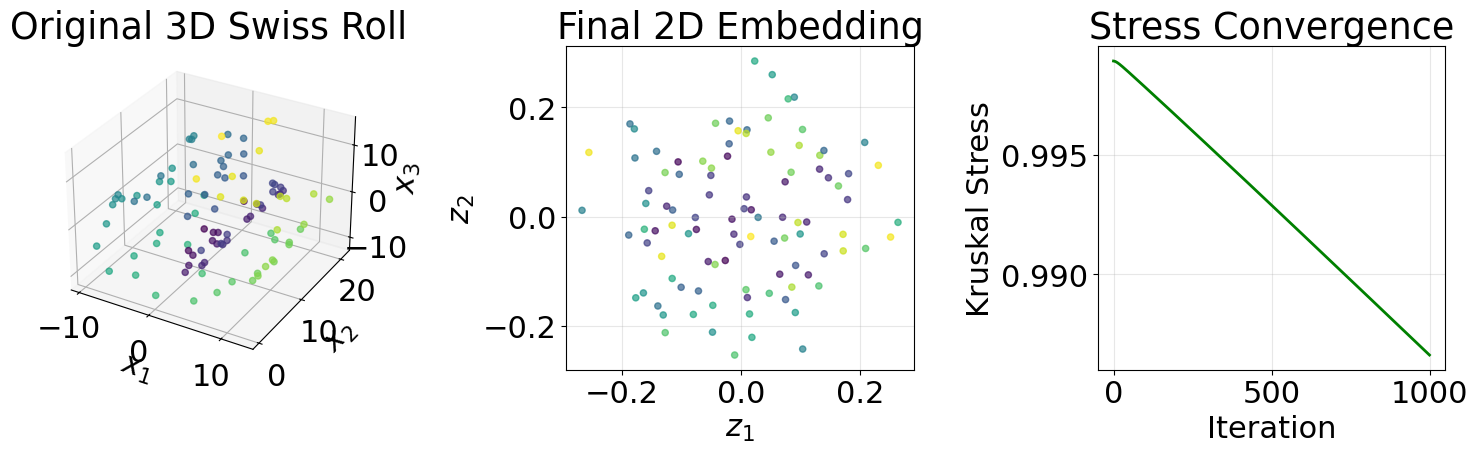

In [36]:
fig = plt.figure(figsize=(15, 5))

# Plot 1: Original 3D Swiss roll
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(X_original[:, 0], X_original[:, 1], X_original[:, 2], 
           c=t_original, cmap='viridis', s=20, alpha=0.7)
ax1.set_title('Original 3D Swiss Roll')
ax1.set_xlabel('$x_1$')
ax1.set_ylabel('$x_2$')
ax1.set_zlabel('$x_3$')

# Plot 2: Final 2D embedding
ax2 = fig.add_subplot(132)
scatter = ax2.scatter(X_final[:, 0], X_final[:, 1], c=t_original, 
                     cmap='viridis', s=20, alpha=0.7)
ax2.set_title('Final 2D Embedding')
ax2.set_xlabel('$z_1$')
ax2.set_ylabel('$z_2$')
ax2.grid(True, alpha=0.3)

# Plot 3: Stress convergence
ax3 = fig.add_subplot(133)
ax3.plot(stress_history, 'g-', linewidth=2)
ax3.set_title('Stress Convergence')
ax3.set_xlabel('Iteration')
ax3.set_ylabel('Kruskal Stress')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
mlai.write_figure("gradient_descent_stress_example.svg", directory="./dimred/")

The gradient descent algorithm successfully reduces the Kruskal stress,
finding a 2D embedding that preserves the pairwise distances from the
original 3D Swiss roll data as well as possible. The convergence plot
shows how the stress decreases over iterations, demonstrating the
optimization process in action. The color coding shows how the algorithm
preserves the underlying manifold structure.

## Effect of Momentum

Let’s compare the performance of gradient descent with and without
momentum to demonstrate the speedup:

In [ ]:
# Compare gradient descent with and without momentum
import time

# Without momentum
print("Running gradient descent without momentum...")
start_time = time.time()
X_no_momentum, stress_history_no_momentum = gradient_descent_stress(
    X_init, D_original, 
    learning_rate=0.01, 
    momentum=0.0,  # No momentum
    max_iterations=200,
    tolerance=1e-8
)
time_no_momentum = time.time() - start_time

# With momentum
print("\nRunning gradient descent with momentum...")
start_time = time.time()
X_momentum, stress_history_momentum = gradient_descent_stress(
    X_init, D_original, 
    learning_rate=0.01, 
    momentum=0.9,  # With momentum
    max_iterations=200,
    tolerance=1e-8
)
time_momentum = time.time() - start_time

print(f"\nNo momentum: {len(stress_history_no_momentum)} iterations, {time_no_momentum:.2f}s")
print(f"With momentum: {len(stress_history_momentum)} iterations, {time_momentum:.2f}s")
print(f"Speedup: {time_no_momentum/time_momentum:.1f}x")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Convergence comparison
axes[0].plot(stress_history_no_momentum, 'b-', linewidth=2, label='No Momentum')
axes[0].plot(stress_history_momentum, 'r-', linewidth=2, label='With Momentum')
axes[0].set_title('Convergence Comparison')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Kruskal Stress')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Final embeddings comparison
axes[1].scatter(X_no_momentum[:, 0], X_no_momentum[:, 1], c=t_original, 
               cmap='viridis', s=20, alpha=0.7, label='No Momentum')
axes[1].set_title('Final Embeddings')
axes[1].set_xlabel('$z_1$')
axes[1].set_ylabel('$z_2$')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
mlai.write_figure("momentum_comparison.svg", directory="./dimred/")

## Comparison with Classical MDS

Let’s compare our iterative approach with the classical MDS solution to
see how they perform:

In [ ]:
# Classical MDS solution
from sklearn.manifold import MDS

mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
X_mds = mds.fit_transform(D_original)

# Compare stress values
stress_gd = kruskal_stress(D_original, squareform(pdist(X_momentum)))
stress_mds = kruskal_stress(D_original, squareform(pdist(X_mds)))

print(f"Gradient Descent (with momentum) Stress: {stress_gd:.6f}")
print(f"Classical MDS Stress: {stress_mds:.6f}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gradient descent result
scatter1 = axes[0].scatter(X_momentum[:, 0], X_momentum[:, 1], c=t_original, 
                          cmap='viridis', s=20, alpha=0.7)
axes[0].set_title(f'Gradient Descent + Momentum (Stress: {stress_gd:.4f})')
axes[0].set_xlabel('$z_1$')
axes[0].set_ylabel('$z_2$')
axes[0].grid(True, alpha=0.3)

# Classical MDS result
scatter2 = axes[1].scatter(X_mds[:, 0], X_mds[:, 1], c=t_original, 
                          cmap='viridis', s=20, alpha=0.7)
axes[1].set_title(f'Classical MDS (Stress: {stress_mds:.4f})')
axes[1].set_xlabel('$z_1$')
axes[1].set_ylabel('$z_2$')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
mlai.write_figure("gradient_descent_vs_mds.svg", directory="./dimred/")

Both methods achieve similar results, with classical MDS typically
providing the global optimum for this type of problem. However, the
iterative gradient descent approach is more flexible and can be extended
to handle constraints, non-Euclidean distances, and other modifications
that would be difficult with classical methods.

## Local vs Global Structure Preservation

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_dimred/includes/local-vs-global-preservation.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_dimred/includes/local-vs-global-preservation.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

An important consideration in dimensionality reduction is whether to
focus on preserving local or global structure. Local methods like LLE
and t-SNE excel at preserving local neighborhood relationships but may
distort global structure, while methods like classical MDS attempt to
preserve all pairwise distances.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import mlai.plot as plot

In [ ]:
from mlai import generate_swiss_roll
import inspect
file_path = inspect.getfile(generate_swiss_roll)

In [ ]:
%load -s generate_swiss_roll {file_path}

In [ ]:
# Generate and plot Swiss roll
X, t = generate_swiss_roll()
fig = plt.figure(figsize=plot.big_wide_figsize)
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=t, cmap=plt.cm.viridis)
ax.view_init(10, -70)
ax.set_title('Swiss Roll: Example of Global Structure')

The Swiss roll is a classic example where preserving only local
structure can fail. Points that are close in the ambient space may be
far apart on the manifold - this is known as the “short-circuiting”
problem.

<img src="https://mlatcl.github.io/mlfc/./slides/diagrams//dimred/short-circuit-problem.svg" class="" width="" style="vertical-align:middle;">

Figure: <i>The short-circuiting problem occurs when points that are
close in the ambient space are actually far apart on the manifold.</i>

## t-SNE

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_dimred/includes/t-sne-intro.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_dimred/includes/t-sne-intro.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

t-Distributed Stochastic Neighbor Embedding (t-SNE) is a dimensionality
reduction technique that focuses on preserving local structure. It
converts distances between points into probabilities and tries to match
these probabilities in the low-dimensional space.

The idea in t-SNE is to convert distances in data space into
probabilities. This is done through two stages. First a neighbourhood
graph is formed, so each point, $i$, is related to its $k$ nearest
neighbours.

If the squared distances between two data points are given by
$d_{i,j}^2$, then the probability of point $i$ linking to point $j$ is
given by, $$
p(r_{i,j} | \mathbf{ \MakeUppercase{d}}) = \pi_{i,j} =  \frac{\exp -\frac{d_{i,j}^2}{2\sigma^2}}{\sum_{k\in \mathscr{N}\left( i \right)}\exp -d_{i,j}}
$$ where $r_{i,j} = 1$ if the two points are linked, $\pi_{i,j}$ is the
probability of that link and the neighbourhood of $i$ is given by
$\mathscr{N}(i)$.

This is compared with probabilities in *latent* space which are given by
$$
p(s_{i,j} | \boldsymbol{ \Delta}) = q_{i,j} = (1 + \delta_{i,j})^(-1),
$$ where $s_{i,j} = 1$ if two points are linked in the latent space and
$q_{i,j}$ is the probability of that link. The latent distances are
given by $$
\delta_{i,j} = (\mathbf{ z}_{i, :} - \mathbf{ z}_{j, :})^\top*\mathbf{ z}_{i, :} - \mathbf{ z}_{j, :}).
$$}

$t$-SNE then minimises the KL divergence between these two link
distributions. $$
E(\mathbf{Z}= \sum_i \sum_{j\in\mathscr{N}\left( i \right)} p_{i,k} \log \frac{p_{i,k}}{q_{i,k}}
$$}

The approach was originally proposed by Hinton and Roweis (n.d.), then
later modified using the $t$-distribution in the latent space by van der
Maaten and Hinton (2008).

The basic idea is to minimise the Kullback-Leibler divergence between a
distribution defined in the latent space and a distribution defined in
the data space. The distribution is over neighbours in each space, by
definition the probability of point $j$ being selected as a neighbor of
point $i$ is:

$$p_{j|i} = \frac{\exp(-\|\mathbf{ y}_i - \mathbf{ y}_j\|^2/2\sigma_i^2)}{\sum_{k \neq i} \exp(-\|\mathbf{ y}_i - \mathbf{ y}_k\|^2/2\sigma_i^2)}$$

where $\sigma_i$ is chosen to achieve a desired perplexity. In the
low-dimensional space, a t-distribution is used instead:

$$q_{ij} = \frac{(1 + \|\mathbf{ z}_i - \mathbf{ z}_j\|^2)^{-1}}{\sum_{k \neq l} (1 + \|\mathbf{ z}_k - \mathbf{ z}_l\|^2)^{-1}}$$

In [ ]:
from sklearn.manifold import TSNE

In [ ]:
from mlai.plot import tsne_example
import inspect
file_path = inspect.getfile(tsne_example)

In [ ]:
%load -s tsne_example {file_path}

## Oil Flow Data

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_datasets/includes/oil-flow-data.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_datasets/includes/oil-flow-data.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

This data set is from a physics-based simulation of oil flow in a
pipeline. The data was generated as part of a project to determine the
fraction of oil, water and gas in North Sea oil pipes (Bishop and James,
1993).

In [ ]:
import pods

In [ ]:
data = pods.datasets.oil()

The data consists of 1000 12-dimensional observations of simulated oil
flow in a pipeline. Each observation is labelled according to the
multi-phase flow configuration (homogeneous, annular or laminar).

In [ ]:
# Convert data["Y"] from [1, -1, -1] in each row to rows of 0 or 1 or 2
Y = data["Y"]
# Find rows with 1 in first column (class 0)
class0 = (Y[:, 0] == 1).astype(int) * 0
# Find rows with 1 in second column (class 1) 
class1 = (Y[:, 1] == 1).astype(int) * 1
# Find rows with 1 in third column (class 2)
class2 = (Y[:, 2] == 1).astype(int) * 2
# Combine into single array of class labels 0,1,2
labels = class0 + class1 + class2

The data is returned as a dictionary containing training and test inputs
(‘X,’ ‘Xtst’), training and test labels (‘Y,’ ‘Ytst’), and the names of
the features.

In [ ]:
import matplotlib.pyplot as plt
import mlai.plot as plot
import mlai
import numpy as np

In [ ]:
fig, ax = plt.subplots(figsize=plot.big_wide_figsize)
# Plot first two dimensions of the data
classes = np.unique(labels)
colors = ['r', 'g', 'b']
for i, cls in enumerate(classes):
    idx = data['Y'] == cls
    ax.plot(data['X'][idx, 0], data['X'][idx, 1], colors[i] + '.', 
            markersize=10, label=f'Class {cls}')
ax.set_xlabel('1st dimension')
ax.set_ylabel('2nd dimension')
ax.legend()

mlai.write_figure('oil-flow-data.svg', directory='./datasets')

<img src="https://mlatcl.github.io/mlfc/./slides/diagrams//datasets/oil-flow-data.svg" class="" width="80%" style="vertical-align:middle;">

Figure: <i>Visualization of the first two dimensions of the oil flow
data from Bishop and James (1993)</i>

As normal we include the citation information for the data.

In [ ]:
print(data['citation'])

And extra information about the data is included, as standard, under the
keys `info` and `details`.

In [ ]:
print(data['details'])

In [ ]:
X = data['X']
Y = data['Y']

In [ ]:
import matplotlib.pyplot as plt
import mlai
from mlai import plot

In [ ]:
tsne_example(X, Y)
mlai.write_figure('t-sne-oil-flow.svg', directory='./dimred')

<img src="https://mlatcl.github.io/mlfc/./slides/diagrams//dimred/t-sne-oil-flow.svg" class="" width="80%" style="vertical-align:middle;">

Figure: <i>t-SNE embedding of the oil flow data.</i>

The perplexity parameter in t-SNE effectively controls how to balance
attention between local and global aspects of the data. It can be
interpreted as a smooth measure of the effective number of neighbors.

## UMAP

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_dimred/includes/umap-intro.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_dimred/includes/umap-intro.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

Uniform Manifold Approximation and Projection (UMAP) is a dimensionality
reduction technique that builds on ideas from manifold learning and
topological data analysis. It provides similar visualization quality to
t-SNE but with better preservation of global structure and faster
computation times.

UMAP constructs a weighted graph, for points $\mathbf{ y}_i$ and
$\mathbf{ y}_j$, the weight is:

$$w_{ij} = \exp\left(\frac{-d(\mathbf{ y}_i, \mathbf{ y}_j) - \rho_i}{\sigma_i}\right)$$

where $\rho_i$ is the distance to the nearest neighbor of $i$, and
$\sigma_i$ is chosen to achieve a desired local connectivity. This forms
a high-dimensional fuzzy topological representation which UMAP then
tries to approximate in lower dimensions.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import mlai.plot as plot
from sklearn.datasets import make_moons

In [ ]:
def compare_umap_tsne(n_samples=1000, noise=0.1, 
                         random_state=42):
    """Compare UMAP and t-SNE on the two moons dataset"""
    # Generate data
    X, labels = make_moons(n_samples=n_samples, 
                          noise=noise, 
                          random_state=random_state)
    
    # Create figure
    fig, (ax1, ax2) = plt.subplots(1, 2, 
                                  figsize=plot.two_figsize)
    
    # t-SNE embedding
    from sklearn.manifold import TSNE
    tsne = TSNE(n_components=2, random_state=random_state)
    X_tsne = tsne.fit_transform(X)
    ax1.scatter(X_tsne[:, 0], X_tsne[:, 1], 
                c=labels, cmap=plt.cm.viridis)
    ax1.set_title('t-SNE')
    
    # UMAP embedding
    import umap
    reducer = umap.UMAP(random_state=random_state)
    X_umap = reducer.fit_transform(X)
    ax2.scatter(X_umap[:, 0], X_umap[:, 1], 
                c=labels, cmap=plt.cm.viridis)
    ax2.set_title('UMAP')
    
    plt.tight_layout()
    return fig

UMAP has several advantages over t-SNE:

1.  **Speed**: UMAP is significantly faster than t-SNE, especially for
    large datasets
2.  **Global Structure**: UMAP often preserves more of the global
    structure of the data
3.  **Theoretical Foundation**: UMAP has strong mathematical foundations
    in topology
4.  **Versatility**: Can be used for general dimensionality reduction,
    not just visualization

## UMAP Parameters

UMAP’s behavior can be controlled through several key parameters:

-   `n_neighbors`: Controls how local/global the embedding is (similar
    to perplexity in t-SNE)
-   `min_dist`: Controls how tightly points are allowed to pack together
-   `metric`: The distance metric used in the high-dimensional space

In [ ]:
def plot_umap_params(X, labels, 
                        n_neighbors=[5, 15, 50], 
                        min_dist=[0.1, 0.5, 0.9],
                        random_state=42):
    """Plot UMAP embeddings with different parameter settings"""
    fig, axes = plt.subplots(len(n_neighbors), len(min_dist), 
                            figsize=(5*len(min_dist), 
                                   5*len(n_neighbors)))
    
    for i, nn in enumerate(n_neighbors):
        for j, md in enumerate(min_dist):
            reducer = umap.UMAP(n_neighbors=nn,
                              min_dist=md,
                              random_state=random_state)
            X_umap = reducer.fit_transform(X)
            axes[i,j].scatter(X_umap[:, 0], X_umap[:, 1],
                            c=labels, cmap=plt.cm.viridis)
            axes[i,j].set_title(f'n_neighbors={nn}, min_dist={md}')
    
    plt.tight_layout()
    return fig

Unlike t-SNE, UMAP can also be used to learn a reusable transformation.
This means it can: 1. Transform new data points without rerunning the
entire algorithm 2. Be used as part of a larger machine learning
pipeline 3. Support supervised and semi-supervised dimensionality
reduction

In [ ]:
# Example of supervised UMAP
def supervised_umap_example(X_train, y_train, X_test, y_test,
                          random_state=42):
    """Demonstrate supervised UMAP"""
    # Fit UMAP with labels
    reducer = umap.UMAP(n_neighbors=15,
                       min_dist=0.1,
                       random_state=random_state)
    reducer.fit(X_train, y=y_train)
    
    # Transform test data
    X_test_umap = reducer.transform(X_test)
    
    # Plot results
    fig, ax = plt.subplots(figsize=plot.big_figsize)
    scatter = ax.scatter(X_test_umap[:, 0], 
                        X_test_umap[:, 1],
                        c=y_test, 
                        cmap=plt.cm.viridis)
    plt.colorbar(scatter)
    ax.set_title('Supervised UMAP Embedding')
    return fig

## Comparing Dimensionality Reduction Methods

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_dimred/includes/dimensionality-reduction-comparison.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_dimred/includes/dimensionality-reduction-comparison.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

Different dimensionality reduction methods have different strengths and
are suited to different tasks. Here’s a comparison of the main
approaches we’ve covered:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import mlai.plot as plot

In [ ]:
def compare_dim_reduction_methods(X, labels, random_state=42):
    """Compare different dimensionality reduction methods"""
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, 
                                    figsize=plot.big_wide_figsize)
    
    # PCA
    from sklearn.decomposition import PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    ax1.scatter(X_pca[:, 0], X_pca[:, 1], 
                c=labels, cmap=plt.cm.viridis)
    ax1.set_title('PCA')
    
    # MDS
    from sklearn.manifold import MDS
    mds = MDS(n_components=2, random_state=random_state)
    X_mds = mds.fit_transform(X)
    ax2.scatter(X_mds[:, 0], X_mds[:, 1], 
                c=labels, cmap=plt.cm.viridis)
    ax2.set_title('MDS')
    
    # t-SNE
    from sklearn.manifold import TSNE
    tsne = TSNE(n_components=2, random_state=random_state)
    X_tsne = tsne.fit_transform(X)
    ax3.scatter(X_tsne[:, 0], X_tsne[:, 1], 
                c=labels, cmap=plt.cm.viridis)
    ax3.set_title('t-SNE')
    
    # UMAP
    import umap
    reducer = umap.UMAP(random_state=random_state)
    X_umap = reducer.fit_transform(X)
    ax4.scatter(X_umap[:, 0], X_umap[:, 1], 
                c=labels, cmap=plt.cm.viridis)
    ax4.set_title('UMAP')
    
    plt.tight_layout()
    return fig

Here’s a summary of when to use each method:

1.  **PCA**:

    -   When you need interpretable features
    -   When computational speed is important
    -   When the data has a linear structure

2.  **MDS**:

    -   When you have only distance/similarity information
    -   When you want to preserve all pairwise distances
    -   When you need a non-linear embedding

3.  **t-SNE**:

    -   When creating visualizations is the primary goal
    -   When local structure is more important than global structure
    -   When you have up to a few thousand points

4.  **UMAP**:

    -   When you need faster computation than t-SNE
    -   When both local and global structure are important
    -   When you need a reusable transformation
    -   When you want to incorporate label information

## Thanks!

For more information on these subjects and more you might want to check
the following resources.

-   company: [Trent AI](https://trent.ai)
-   book: [The Atomic
    Human](https://www.penguin.co.uk/books/455130/the-atomic-human-by-lawrence-neil-d/9780241625248)
-   twitter: [@lawrennd](https://twitter.com/lawrennd)
-   podcast: [The Talking Machines](http://thetalkingmachines.com)
-   newspaper: [Guardian Profile
    Page](http://www.theguardian.com/profile/neil-lawrence)
-   blog:
    [http://inverseprobability.com](http://inverseprobability.com/blog.html)

::: {.cell .markdown}

## References

Bishop, C.M., James, G.D., 1993. Analysis of multiphase flows using
dual-energy gamma densitometry and neural networks. Nuclear Instruments
and Methods in Physics Research A327, 580–593.
<https://doi.org/10.1016/0168-9002(93)90728-Z>

Hinton, G.E., Roweis, S.T., n.d. Stochastic neighbor embedding. pp.
857–864.

Koch, K., McLean, J., Segev, R., Freed, M.A., Berry II, M.J.,
Balasubramanian, V., Sterling, P., 2006. How much the eye tells the
brain. Current Biology 16, 1428–1434.
<https://doi.org/10.1016/j.cub.2006.05.056>

Lawrence, N.D., 2024. The atomic human: Understanding ourselves in the
age of AI. Allen Lane.

MacKay, D.M., 1991. Behind the eye. Basil Blackwell.

O’Regan, J.K., 2011. Why red doesn’t sound like a bell: Understanding
the feel of consciousness. Oxford University Press, Oxford.

van der Maaten, L.J.P., Hinton, G.E., 2008. Visualizing data using
t-SNE. Journal of Machine Learning Research 9, 2579–2605.